# 1. Phase integration

In [1]:
import numpy as np
import h5py
import os
import time

from aux_functions import order_parameter, timer
from integration_functions import kuramoto_sakaguchi_euler

## Time-dependent noise

In [ ]:
## Handle with care!!!!

# os.remove("OutputTimedep/Solutions_delta0.h5")
# os.remove("OutputTimedep/Solutions_deltaatan5.h5")

In [14]:
# 1D ring
L = 1000
K = 1
T = 20000 ## a bit above 100000 to allow for the next log-scale datapoint (startsampling*multsampling**n) to be included.     
Nt = 2000000
startsampling = 100
multsampling = 1.6
D = 0.01
M0 = 0
M = 2

for delta, deltaname in zip([0, np.arctan(5)], ["0","atan5"]):

    print("## Delta", deltaname)

    with timer():
        
        with h5py.File(f"OutputTimeDep/Solutions_delta{deltaname}.h5", "a") as f:
                
            print("dt=", T/Nt)
            
            sim = f.create_group("Parameters")
        
            sim.attrs["L"] = L
            sim.attrs["K"] = K
            sim.attrs["delta"] = delta
            sim.attrs["T"] = T
            sim.attrs["Nt"] = Nt
            sim.attrs["startsampling"] = startsampling
            sim.attrs["multsampling"] = multsampling
            sim.attrs["D"] = D
            
            for seed in range(M0, M0 + M):
    
                if seed % 100 == 0:
                    print(seed)
                    
                # Create a simulation object within the file, 
                sim = f.create_group(str(seed))
        
                ####### TO DO #### DE-RANDOMIZE THIS ######
                omega = np.random.uniform(low=1, high=-1, size=L)
                sim.create_dataset("omega", data = omega)
                
                # theta0 = np.random.uniform(0, 2*np.pi, size=L)
                theta0 = np.zeros((L,1))
                    
                # as well as the fields computed
                t, phases = kuramoto_sakaguchi_euler("1d", L, omega, K, delta, theta0, T, Nt, startsampling=startsampling, multsampling=multsampling, stochastic=D, seed=seed)
                R, Psi = order_parameter(phases)
                
                sim.create_dataset("t", data = t)
                sim.create_dataset("phases", data = phases)
                sim.create_dataset("R", data = R)
                sim.create_dataset("Psi", data = Psi)
                
            print("Seeds:", list(f))
            print("Attributes:", dict(sim.attrs))
            print("Contents:", list(sim.keys()))
            
            # Create a simulation object for the average over realizations 
            sim = f.create_group("AverageSims")


## Delta 0
dt= 0.01
0
Seeds: ['0', '1', 'Parameters']
Attributes: {}
Contents: ['Psi', 'R', 'omega', 'phases', 't']
This chunk of code took 303.17147502000444 seconds.
## Delta atan5
dt= 0.01
0
Seeds: ['0', '1', 'Parameters']
Attributes: {}
Contents: ['Psi', 'R', 'omega', 'phases', 't']
This chunk of code took 318.25827883399324 seconds.


In [5]:
phases.shape

(15, 1000)

In [17]:
303 * 200 /60/60

16.833333333333332

## Columnar noise

In [ ]:
## Handle with care!!!!

# os.remove("OutputColumnar/Solutions_delta0.h5")
# os.remove("OutputColumnar/Solutions_deltaatan5.h5")

In [3]:
# 1D ring
L = 1000
K = 1
T = 1200 ## a bit above 100000 to allow for the next log-scale datapoint (startsampling*multsampling**n) to be included.     
Nt = 120000
startsampling = 100
multsampling = 1.4
D = 0.01
M = 1

for delta, deltaname in zip([0, np.arctan(5)], ["0","atan5"]):

    print("## Delta", deltaname)

    with timer():
        
        with h5py.File(f"OutputData/Solutions_delta{deltaname}.h5", "a") as f:
                
            print("dt=", T/Nt)
            
            sim = f.create_group("Parameters")
        
            sim.attrs["L"] = L
            sim.attrs["K"] = K
            sim.attrs["delta"] = delta
            sim.attrs["T"] = T
            sim.attrs["Nt"] = Nt
            sim.attrs["startsampling"] = startsampling
            sim.attrs["multsampling"] = multsampling
            sim.attrs["D"] = D
            
            for seed in range(M):
    
                if seed % 100 == 0:
                    print(seed)
                    
                # Create a simulation object within the file, 
                sim = f.create_group(str(seed))
        
                ####### TO DO #### DE-RANDOMIZE THIS ######
                omega = np.random.uniform(low=1, high=-1, size=L)
                sim.create_dataset("omega", data = omega)
                
                # theta0 = np.random.uniform(0, 2*np.pi, size=L)
                theta0 = np.zeros((L,1))
                    
                # as well as the fields computed
                t, phases = kuramoto_sakaguchi_euler("1d", L, omega, K, delta, theta0, T, Nt, startsampling=startsampling, multsampling=multsampling, stochastic=D, seed=seed)
                R, Psi = order_parameter(phases)
                
                sim.create_dataset("t", data = t)
                sim.create_dataset("phases", data = phases)
                sim.create_dataset("R", data = R)
                sim.create_dataset("Psi", data = Psi)
                
            print("Seeds:", list(f))
            print("Attributes:", dict(sim.attrs))
            print("Contents:", list(sim.keys()))
            
            # Create a simulation object for the average over realizations 
            sim = f.create_group("AverageSims")


## Delta 0
dt= 0.01
0
Seeds: ['0', 'Parameters']
Attributes: {}
Contents: ['Psi', 'R', 'omega', 'phases', 't']
This chunk of code took 15.06323692802107 seconds.
## Delta atan5
dt= 0.01
0
Seeds: ['0', 'Parameters']
Attributes: {}
Contents: ['Psi', 'R', 'omega', 'phases', 't']
This chunk of code took 15.890474548039492 seconds.


## Preliminary inspection of the computed quantities

In [8]:
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(["science","no-latex"])

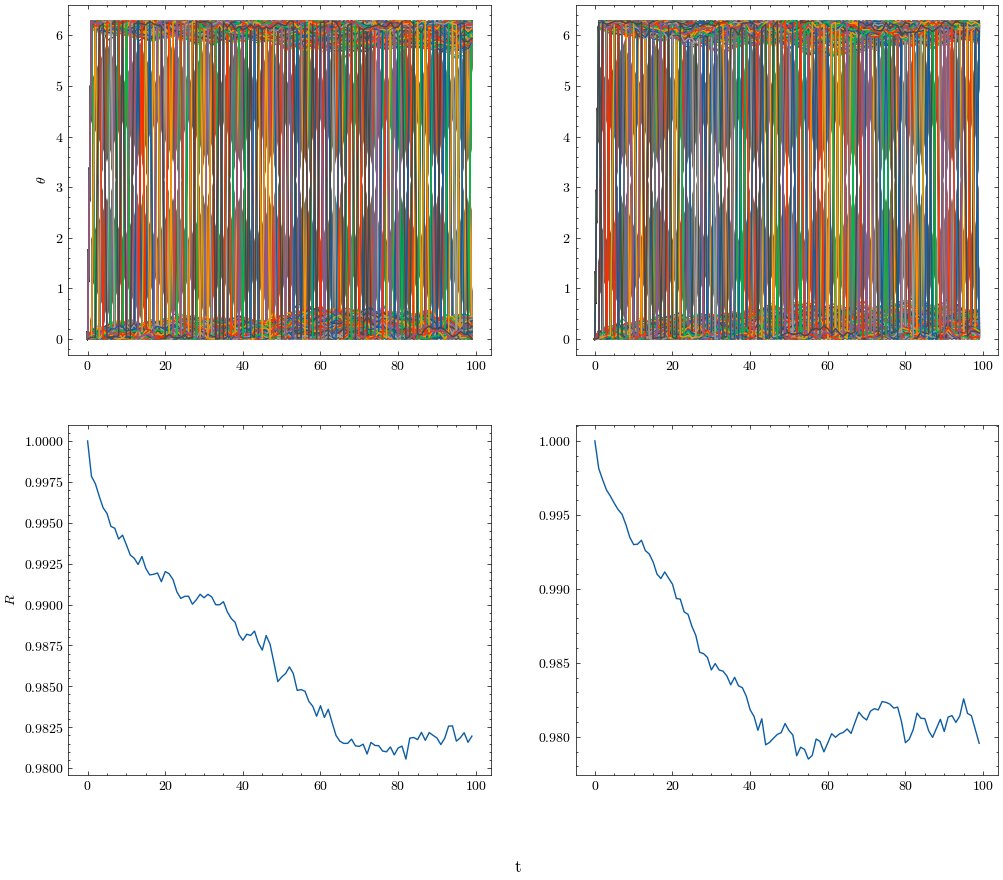

In [8]:
with h5py.File("OutputData/Solutions_delta0.h5", "a") as f:
    
    fig, ax = plt.subplots(2, 2, figsize=(12,10))
    fig.supxlabel("t")
    
    sim = f["0"]    
    ax[0,0].plot(sim["t"][:], sim["phases"][:] % (2 * np.pi))
    ax[1,0].plot(sim["t"][:], sim["R"][:])
    ax[0,0].set_ylabel(r"$\theta$")
    ax[1,0].set_ylabel(r"$R$")
    
    sim = f["1"]
    ax[0,1].plot(sim["t"][:], sim["phases"][:] % (2 * np.pi))
    ax[1,1].plot(sim["t"][:], sim["R"][:])

    plt.tight_layout()
    plt.show()
    

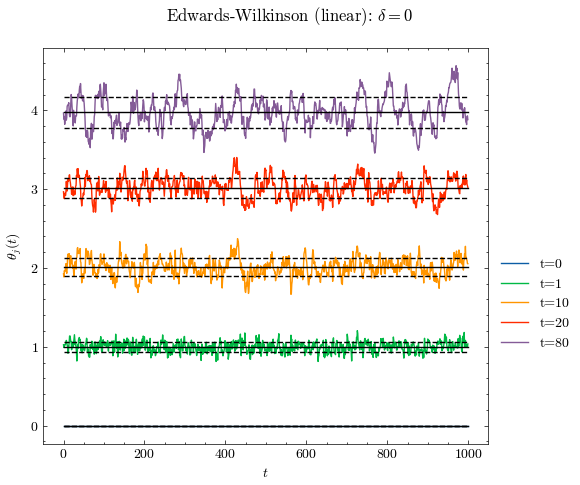

In [20]:
with h5py.File("OutputData/Solutions_delta0.h5", "a") as f:
    
    L = f["Parameters"].attrs["L"]
    
    sim = f["0"]
    
    phases = sim["phases"][:]

    fig, ax = plt.subplots(1, 1, figsize=(6,5))
    fig.suptitle(r"Edwards-Wilkinson (linear): $\delta=0$")
    ax.set_ylabel(r"$\theta_j(t)$")
    ax.set_xlabel(r"$t$")
    
    for ti, displace in zip([0,1,10,20,80], [0,1,2,3,4]):
        ax.plot(range(L), phases[ti,:] + displace, label = f"t={ti}")
        ax.plot(range(L), L * [np.mean(phases[ti,:]) + displace], color="k")
        ax.plot(range(L), L * [np.mean(phases[ti,:]) + np.std(phases[ti,:]) + displace], color="k", linestyle="--")
        ax.plot(range(L), L * [np.mean(phases[ti,:]) - np.std(phases[ti,:]) + displace], color="k", linestyle="--")

    ax.legend(bbox_to_anchor=(1,0.5))

    plt.tight_layout()
    plt.show()
    

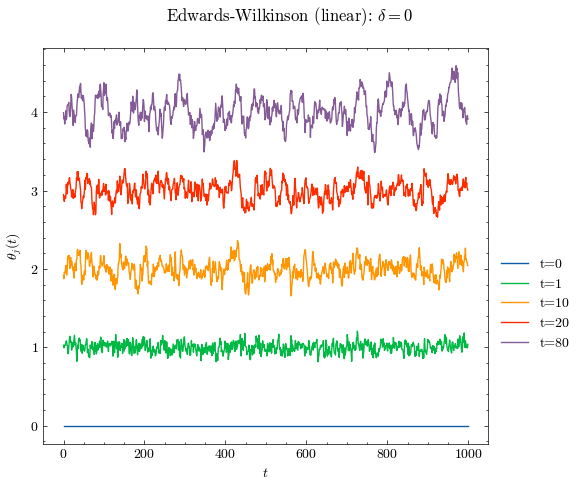

In [27]:
with h5py.File("OutputData/Solutions_delta0.h5", "a") as f:
    
    L = f["Parameters"].attrs["L"]
    
    sim = f["0"]
    
    phases = sim["phases"][:]

    fig, ax = plt.subplots(1, 1, figsize=(6,5))
    fig.suptitle(r"Edwards-Wilkinson (linear): $\delta=0$")
    ax.set_ylabel(r"$\theta_j(t)$")
    ax.set_xlabel(r"$t$")
    
    for ti, displace in zip([0,1,10,20,80], [0,1,2,3,4]):
        ax.plot(range(L), phases[ti,:] + displace - np.mean(phases[ti,:]), label = f"t={ti}")

    ax.legend(bbox_to_anchor=(1,0.5))

    plt.tight_layout()
    plt.show()
    

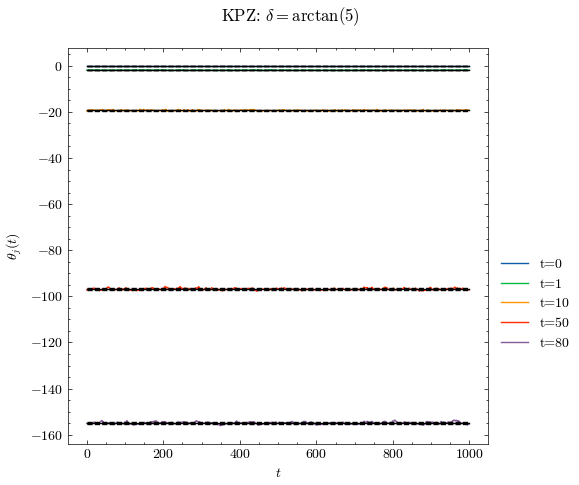

In [24]:
with h5py.File("OutputData/Solutions_deltaatan5.h5", "a") as f:
    
    L = f["Parameters"].attrs["L"]
    
    sim = f["0"]
    
    phases = sim["phases"][:]

    fig, ax = plt.subplots(1, 1, figsize=(6,5))
    fig.suptitle(r"KPZ: $\delta=\arctan(5)$")
    ax.set_ylabel(r"$\theta_j(t)$")
    ax.set_xlabel(r"$t$")
    
    for ti, displace in zip([0,1,10,50,80], [0,0,0,0,0]):
        ax.plot(range(L), phases[ti,:] + displace, label = f"t={ti}")
        ax.plot(range(L), L * [np.mean(phases[ti,:]) + displace], color="k")
        ax.plot(range(L), L * [np.mean(phases[ti,:]) + np.std(phases[ti,:]) + displace], color="k", linestyle="--")
        ax.plot(range(L), L * [np.mean(phases[ti,:]) - np.std(phases[ti,:]) + displace], color="k", linestyle="--")

    ax.legend(bbox_to_anchor=(1,0.5))
    
    plt.tight_layout()
    plt.show()
    

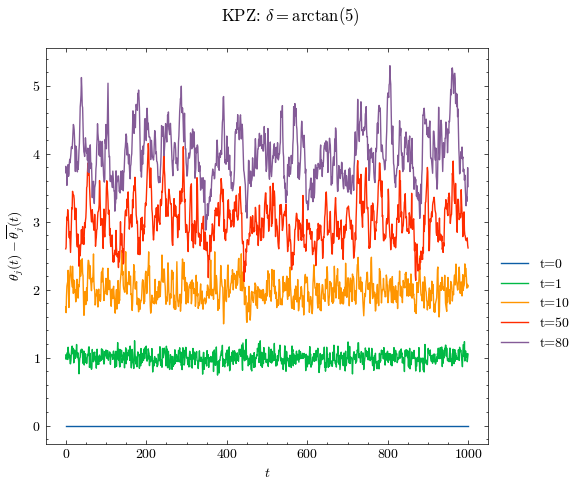

In [13]:
with h5py.File("OutputData/Solutions_oldsampling/Solutions_deltaatan5.h5", "a") as f:
    
    L = f["Parameters"].attrs["L"]
    
    sim = f["0"]
    
    phases = sim["phases"][:]

    fig, ax = plt.subplots(1, 1, figsize=(6,5))
    fig.suptitle(r"KPZ: $\delta=\arctan(5)$")
    ax.set_ylabel(r"$\theta_j(t) - \overline{\theta_j}(t)$")
    ax.set_xlabel(r"$t$")
    
    for ti, displace in zip([0,1,10,50,80], [0,1,2,3,4]):
        ax.plot(range(L), phases[ti,:] + displace - np.mean(phases[ti,:]), label = f"t={ti}")

    ax.legend(bbox_to_anchor=(1,0.5))
    
    plt.tight_layout()
    plt.show()
    